# OREX Results: Replica/Steps Scan and Alpha Collapse (No Fit Curves)

Questo notebook:
1. legge i run OREX (`r = 4,6,8`, `nsteps = 2,4,6`)
2. aggrega accettanza swap e lavoro medio con errore
3. stima `alpha` usando un criterio **non parametrico** di collasso (nessun fit di curva sui dati)
4. plotta i risultati in funzione di

\[x_{\mathrm{eff}} = \frac{N_r}{\sqrt{2^3}} + \alpha\,\frac{n_{steps} N_r^2}{2^3}\]

Mostriamo solo punti + barre d'errore.


In [12]:
from pathlib import Path
import csv
import json
import math
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')


In [13]:
RESULTS_DIR = Path('/Users/eliacellini/Desktop/scripting/neoqcd/results/pt_obc')
TARGET_REPLICAS = {4, 6, 8}
TARGET_STEPS = {2, 4, 6}

ALPHA_MIN = 0.0
ALPHA_MAX = 1.0
N_ALPHA_GRID = 2001

VOL3 = float(2 ** 3)
SQRT_VOL3 = math.sqrt(VOL3)


In [14]:
def xeff(nrep, nsteps, alpha):
    nrep = np.asarray(nrep, dtype=float)
    nsteps = np.asarray(nsteps, dtype=float)
    return nrep / SQRT_VOL3 + alpha * (nsteps * nrep * nrep) / VOL3


def inv_xeff(nrep, nsteps, alpha):
    return 1.0 / xeff(nrep, nsteps, alpha)


def _to_float(x, default=np.nan):
    try:
        return float(x)
    except Exception:
        return default


def _to_int(x, default=0):
    try:
        return int(float(x))
    except Exception:
        return default


def mean_sem_from_moments(sum_x, sum_x2, count):
    n = int(count)
    if n <= 0:
        return np.nan, np.nan
    mean = float(sum_x) / n
    if n == 1:
        return mean, np.nan
    var_unbiased = (float(sum_x2) - (float(sum_x) * float(sum_x) / n)) / (n - 1)
    var_unbiased = max(var_unbiased, 0.0)
    sem = math.sqrt(var_unbiased / n)
    return mean, sem


def row_to_moments(mean_val, sem_val, count):
    n = int(count)
    if n <= 0 or not np.isfinite(mean_val):
        return 0.0, 0.0, 0

    s = float(mean_val) * n

    if n == 1 or not np.isfinite(sem_val):
        return s, float(mean_val) * float(mean_val), n

    var_unbiased = float(sem_val) * float(sem_val) * n
    ssq = var_unbiased * (n - 1) + (s * s) / n
    return s, ssq, n


def load_run(meta_path):
    run_dir = meta_path.parent
    csv_path = run_dir / 'pt_metrics.csv'
    if not csv_path.exists():
        return None

    meta = json.loads(meta_path.read_text())
    args = meta.get('args', {})

    if args.get('algorithm') != 'orex':
        return None

    nrep = _to_int(meta.get('world_size'))
    nsteps = _to_int(args.get('orex_protocol_steps'))

    if nrep not in TARGET_REPLICAS or nsteps not in TARGET_STEPS:
        return None

    total_prop = 0
    total_acc = 0
    work_sum = 0.0
    work_sum_sq = 0.0
    work_count = 0

    with open(csv_path, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            total_prop += _to_int(row.get('swap_n_proposed'), 0)
            total_acc += _to_int(row.get('swap_n_accepted'), 0)

            wm = _to_float(row.get('work_mean'))
            ws = _to_float(row.get('work_sem'))
            wc = _to_int(row.get('work_count'), 0)
            s, ssq, n = row_to_moments(wm, ws, wc)
            work_sum += s
            work_sum_sq += ssq
            work_count += n

    if total_prop > 0:
        acc_mean = total_acc / total_prop
        acc_sem = math.sqrt(acc_mean * (1.0 - acc_mean) / total_prop)
    else:
        acc_mean = np.nan
        acc_sem = np.nan

    work_mean, work_sem = mean_sem_from_moments(work_sum, work_sum_sq, work_count)

    return {
        'run_name': run_dir.name,
        'nrep': nrep,
        'nsteps': nsteps,
        'acc_mean': acc_mean,
        'acc_sem': acc_sem,
        'work_mean': work_mean,
        'work_sem': work_sem,
    }


In [15]:
runs = []
for meta_path in sorted(RESULTS_DIR.glob('*/run_meta.json')):
    rec = load_run(meta_path)
    if rec is not None:
        runs.append(rec)

if not runs:
    raise RuntimeError('Nessun run OREX compatibile trovato.')

runs = sorted(runs, key=lambda d: (d['nrep'], d['nsteps']))

print(f'Run trovati: {len(runs)}')
for r in runs:
    print(
        f"{r['run_name']:<28}  r={r['nrep']}  s={r['nsteps']}  "
        f"acc={r['acc_mean']:.4f}±{r['acc_sem']:.4f}  "
        f"work={r['work_mean']:.4f}±{r['work_sem']:.4f}"
    )


Run trovati: 13
orex_obc_cpu_r4_L2_s1         r=4  s=1  acc=0.1908±0.0057  work=13.2290±0.1938
orex_obc_cpu_r4_L2_s2         r=4  s=2  acc=0.2454±0.0062  work=8.2985±0.1300
orex_obc_cpu_r4_L2_s4         r=4  s=4  acc=0.3296±0.0068  work=4.9114±0.0843
orex_obc_cpu_r4_L2_s6         r=4  s=6  acc=0.3765±0.0070  work=3.4973±0.0640
orex_obc_cpu_r6_L2_s1         r=6  s=1  acc=0.3365±0.0053  work=4.6851±0.0590
orex_obc_cpu_r6_L2_s2         r=6  s=2  acc=0.4191±0.0055  work=2.8115±0.0407
orex_obc_cpu_r6_L2_s4         r=6  s=4  acc=0.5055±0.0056  work=1.6624±0.0274
orex_obc_cpu_r6_L2_s6         r=6  s=6  acc=0.5546±0.0056  work=1.2346±0.0220
orex_obc_cpu_r8_L2_s1         r=8  s=1  acc=0.4388±0.0047  work=2.3445±0.0293
orex_obc_cpu_r8_L2_s2         r=8  s=2  acc=0.5269±0.0047  work=1.4171±0.0209
orex_obc_cpu_r8_L2_s4         r=8  s=4  acc=0.6165±0.0046  work=0.8406±0.0151
orex_obc_cpu_r4_L2            r=8  s=6  acc=0.6641±0.0091  work=nan±nan
orex_obc_cpu_r8_L2_s6         r=8  s=6  acc=0.6584±0.

In [16]:
def by_replica(metric_key, err_key):
    out = {}
    for nrep in sorted(TARGET_REPLICAS):
        sub = [r for r in runs if r['nrep'] == nrep]
        sub = sorted(sub, key=lambda d: d['nsteps'])
        x = np.array([d['nsteps'] for d in sub], dtype=float)
        y = np.array([d[metric_key] for d in sub], dtype=float)
        e = np.array([d[err_key] for d in sub], dtype=float)
        out[nrep] = (x, y, e)
    return out

acc_by_r = by_replica('acc_mean', 'acc_sem')
work_by_r = by_replica('work_mean', 'work_sem')


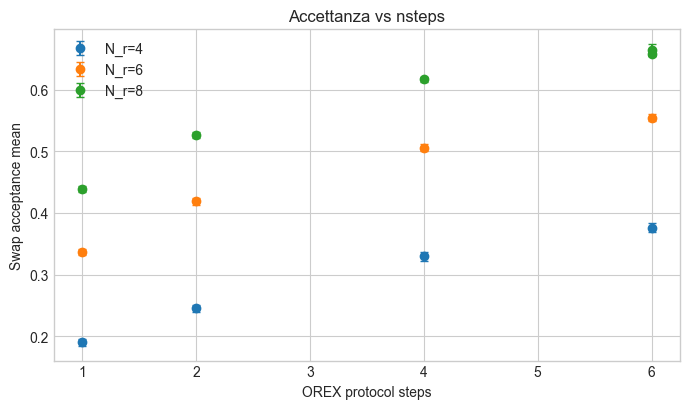

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.2))
for nrep, (x, y, e) in acc_by_r.items():
    ax.errorbar(x, y, yerr=e, fmt='o', capsize=3, label=f'N_r={nrep}')
ax.set_xlabel('OREX protocol steps')
ax.set_ylabel('Swap acceptance mean')
ax.set_title('Accettanza vs nsteps')
ax.legend()
plt.tight_layout()
plt.show()


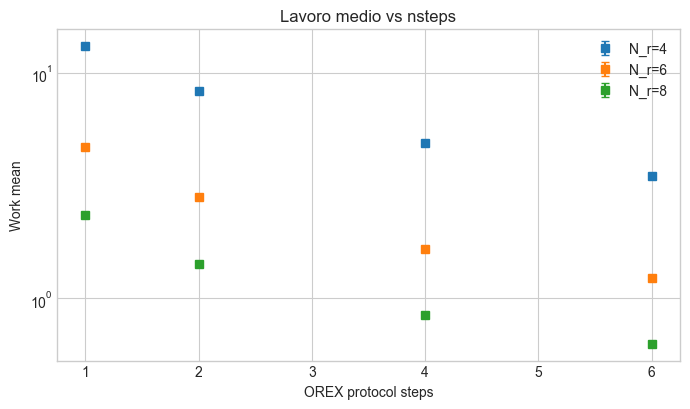

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.2))
for nrep, (x, y, e) in work_by_r.items():
    ax.errorbar(x, y, yerr=e, fmt='s', capsize=3, label=f'N_r={nrep}')
ax.set_xlabel('OREX protocol steps')
ax.set_ylabel('Work mean')
ax.set_yscale('log')
ax.set_title('Lavoro medio vs nsteps')
ax.legend()
plt.tight_layout()
plt.show()


In [19]:
def collapse_score_nonparam(y, e, z):
    y = np.asarray(y, dtype=float)
    e = np.asarray(e, dtype=float)
    z = np.asarray(z, dtype=float)

    mask = np.isfinite(y) & np.isfinite(z)
    y, e, z = y[mask], e[mask], z[mask]

    if len(y) < 3:
        return np.inf

    safe_e = np.where(np.isfinite(e) & (e > 0), e, np.ones_like(e))

    dz = z[:, None] - z[None, :]
    dy = y[:, None] - y[None, :]
    var = safe_e[:, None] ** 2 + safe_e[None, :] ** 2

    tri = np.triu(np.ones_like(dz, dtype=bool), k=1)
    dz = np.abs(dz[tri])
    dy = dy[tri]
    var = var[tri]

    if len(dz) == 0:
        return np.inf

    sigma = np.median(dz)
    if not np.isfinite(sigma) or sigma <= 0:
        sigma = max(np.max(dz), 1e-6)

    w = np.exp(-0.5 * (dz / sigma) ** 2)
    num = np.sum(w * (dy * dy / var))
    den = np.sum(w)
    if den <= 0:
        return np.inf
    return float(num / den)


def estimate_alpha(metric_key, err_key):
    y = np.array([r[metric_key] for r in runs], dtype=float)
    e = np.array([r[err_key] for r in runs], dtype=float)
    nrep = np.array([r['nrep'] for r in runs], dtype=float)
    nsteps = np.array([r['nsteps'] for r in runs], dtype=float)

    alphas = np.linspace(ALPHA_MIN, ALPHA_MAX, N_ALPHA_GRID)
    scores = []
    for a in alphas:
        z = inv_xeff(nrep, nsteps, a)
        s = collapse_score_nonparam(y, e, z)
        scores.append(s)

    scores = np.array(scores)
    idx = int(np.nanargmin(scores))
    return {
        'alpha': float(alphas[idx]),
        'alphas': alphas,
        'scores': scores,
        'score_min': float(scores[idx]),
    }


def estimate_alpha_global():
    acc = estimate_alpha('acc_mean', 'acc_sem')
    work = estimate_alpha('work_mean', 'work_sem')

    # joint score: normalizzo ciascun punteggio sul suo minimo per bilanciare scale
    s_acc = acc['scores'] / max(acc['score_min'], 1e-12)
    s_work = work['scores'] / max(work['score_min'], 1e-12)
    s_tot = s_acc + s_work

    idx = int(np.nanargmin(s_tot))
    return acc, work, {
        'alpha': float(acc['alphas'][idx]),
        'alphas': acc['alphas'],
        'scores': s_tot,
        'score_min': float(s_tot[idx]),
    }


In [20]:
alpha_acc, alpha_work, alpha_global = estimate_alpha_global()

print(f"alpha_acc    = {alpha_acc['alpha']:.6f}  (score={alpha_acc['score_min']:.4f})")
print(f"alpha_work   = {alpha_work['alpha']:.6f}  (score={alpha_work['score_min']:.4f})")
print(f"alpha_global = {alpha_global['alpha']:.6f}  (joint score={alpha_global['score_min']:.4f})")


alpha_acc    = 0.131000  (score=299.7981)
alpha_work   = 0.798000  (score=898.7014)
alpha_global = 0.798000  (joint score=2.0232)


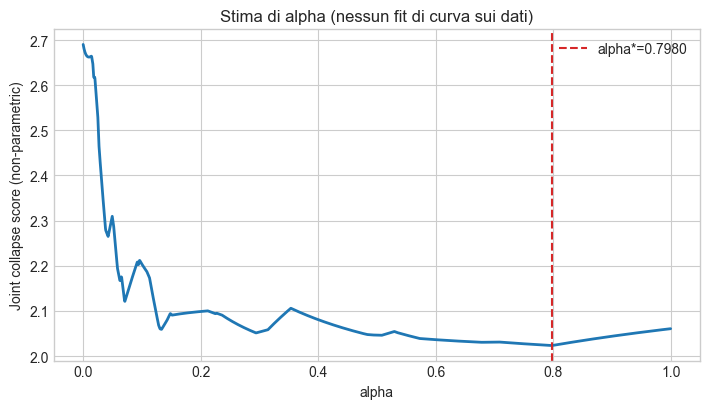

In [21]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(alpha_global['alphas'], alpha_global['scores'], lw=2)
ax.axvline(alpha_global['alpha'], color='tab:red', ls='--', label=f"alpha*={alpha_global['alpha']:.4f}")
ax.set_xlabel('alpha')
ax.set_ylabel('Joint collapse score (non-parametric)')
ax.set_title('Stima di alpha (nessun fit di curva sui dati)')
ax.legend()
plt.tight_layout()
plt.show()


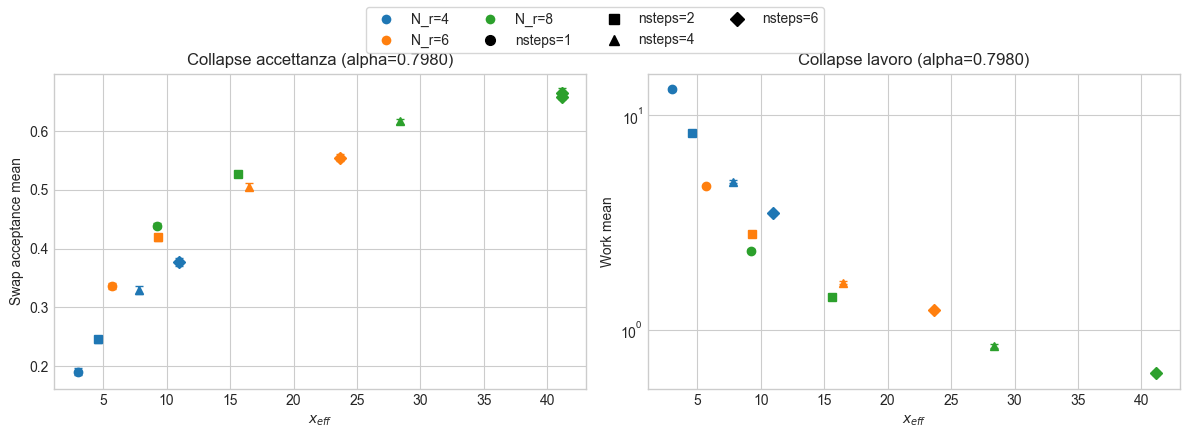

In [22]:
alpha = alpha_global['alpha']

nrep = np.array([r['nrep'] for r in runs], dtype=float)
ns = np.array([r['nsteps'] for r in runs], dtype=float)
x = xeff(nrep, ns, alpha)
acc = np.array([r['acc_mean'] for r in runs], dtype=float)
acc_e = np.array([r['acc_sem'] for r in runs], dtype=float)
work = np.array([r['work_mean'] for r in runs], dtype=float)
work_e = np.array([r['work_sem'] for r in runs], dtype=float)

colors = {4: 'tab:blue', 6: 'tab:orange', 8: 'tab:green'}
markers = {2: 's', 4: '^', 6: 'D'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

ax = axes[0]
for r in sorted(TARGET_REPLICAS):
    for s in sorted(TARGET_STEPS):
        m = (nrep == r) & (ns == s)
        if np.any(m):
            ax.errorbar(x[m], acc[m], yerr=acc_e[m], fmt=markers[s], color=colors[r], capsize=3)
ax.set_xlabel(r'$x_{eff}$')
ax.set_ylabel('Swap acceptance mean')
ax.set_title(f'Collapse accettanza (alpha={alpha:.4f})')

ax = axes[1]
for r in sorted(TARGET_REPLICAS):
    for s in sorted(TARGET_STEPS):
        m = (nrep == r) & (ns == s)
        if np.any(m):
            ax.errorbar(x[m], work[m], yerr=work_e[m], fmt=markers[s], color=colors[r], capsize=3)
ax.set_xlabel(r'$x_{eff}$')
ax.set_ylabel('Work mean')
ax.set_yscale('log')
ax.set_title(f'Collapse lavoro (alpha={alpha:.4f})')

handles = []
labels = []
for r in sorted(TARGET_REPLICAS):
    h = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[r], markersize=8)
    handles.append(h); labels.append(f'N_r={r}')
for s in sorted(TARGET_STEPS):
    h = plt.Line2D([0], [0], marker=markers[s], color='k', linestyle='None', markersize=7)
    handles.append(h); labels.append(f'nsteps={s}')

fig.legend(handles, labels, loc='upper center', ncol=4, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


In [23]:
for r in runs:
    x_r = xeff(r['nrep'], r['nsteps'], alpha_global['alpha'])
    print(
        f"{r['run_name']:<28}  N_r={r['nrep']}  s={r['nsteps']}  "
        f"xeff={x_r:9.4f}  "
        f"acc={r['acc_mean']:.5f}±{r['acc_sem']:.5f}  "
        f"work={r['work_mean']:.5f}±{r['work_sem']:.5f}"
    )


orex_obc_cpu_r4_L2_s1         N_r=4  s=1  xeff=   3.0102  acc=0.19083±0.00567  work=13.22900±0.19377
orex_obc_cpu_r4_L2_s2         N_r=4  s=2  xeff=   4.6062  acc=0.24542±0.00621  work=8.29847±0.12999
orex_obc_cpu_r4_L2_s4         N_r=4  s=4  xeff=   7.7982  acc=0.32958±0.00678  work=4.91143±0.08425
orex_obc_cpu_r4_L2_s6         N_r=4  s=6  xeff=  10.9902  acc=0.37646±0.00699  work=3.49732±0.06400
orex_obc_cpu_r6_L2_s1         N_r=6  s=1  xeff=   5.7123  acc=0.33650±0.00528  work=4.68515±0.05898
orex_obc_cpu_r6_L2_s2         N_r=6  s=2  xeff=   9.3033  acc=0.41913±0.00552  work=2.81147±0.04067
orex_obc_cpu_r6_L2_s4         N_r=6  s=4  xeff=  16.4853  acc=0.50550±0.00559  work=1.66242±0.02737
orex_obc_cpu_r6_L2_s6         N_r=6  s=6  xeff=  23.6673  acc=0.55463±0.00556  work=1.23457±0.02197
orex_obc_cpu_r8_L2_s1         N_r=8  s=1  xeff=   9.2124  acc=0.43884±0.00469  work=2.34451±0.02933
orex_obc_cpu_r8_L2_s2         N_r=8  s=2  xeff=  15.5964  acc=0.52687±0.00472  work=1.41709±0.02091